In [1]:
import numpy as np
import scipy as spi
import skimage as ski

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch

In [8]:
from torchvision.io import decode_image, read_image
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_320_fpn, FasterRCNN_MobileNet_V3_Large_320_FPN_Weights

# Loading the classification models

In [11]:
model = efficientnet_b7(weights=EfficientNet_B7_Weights.IMAGENET1K_V1).eval()
transforms = EfficientNet_B7_Weights.IMAGENET1K_V1.transforms(antialias=True)
categories = EfficientNet_B7_Weights.IMAGENET1K_V1.meta["categories"]
categories

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

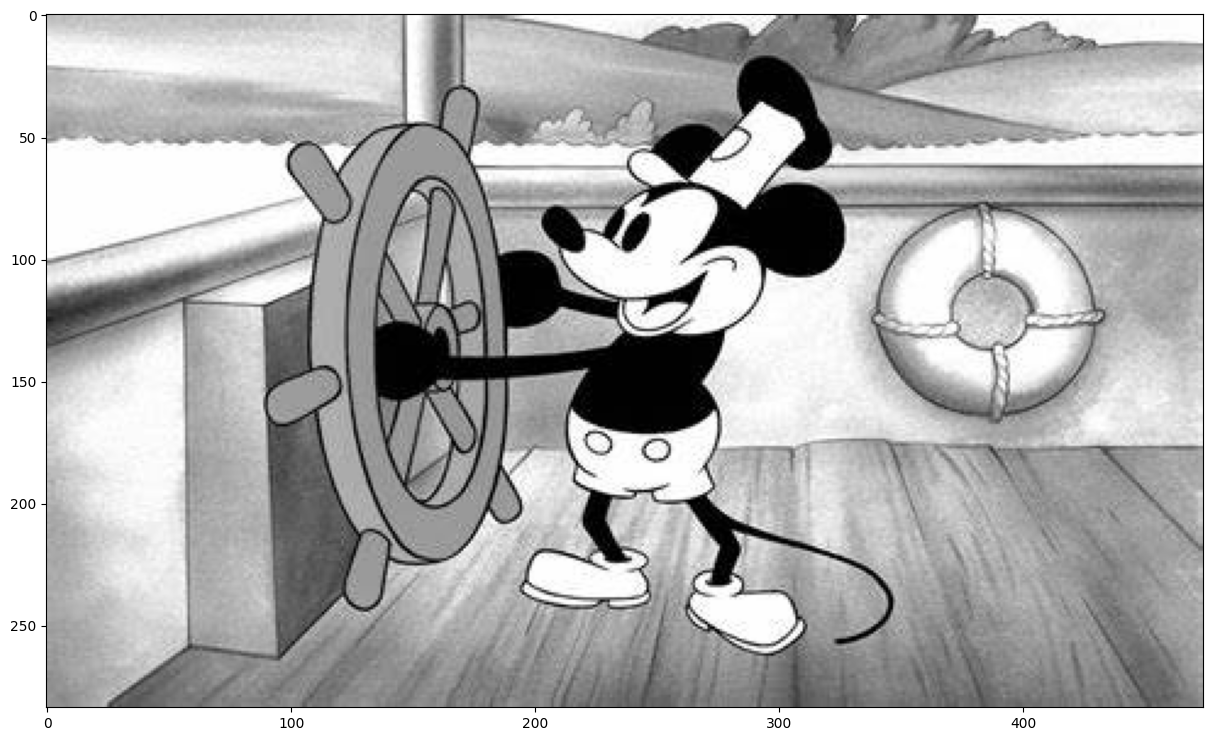

In [12]:
img = read_image("img/willie.jpg")[None]
plt.figure(figsize=(16, 9))
plt.imshow(img[0].permute(1, 2, 0));

In [13]:
with torch.no_grad():
    results = model(transforms(img))[0].softmax(0)

K = 25
top_k = np.argsort(results.numpy())[-K:][::-1]
top_k

array([917, 422, 921, 731, 870, 786, 823, 859, 545, 409, 612, 613, 854,
       745, 846, 700, 794, 751, 619, 807, 577, 804, 861, 471, 999])

In [14]:
for i in top_k:
    print(f"{categories[i]}, {results[i].item():.2f}")

comic book, 0.45
barbell, 0.11
book jacket, 0.02
plunger, 0.01
tricycle, 0.01
sewing machine, 0.01
stethoscope, 0.01
toaster, 0.01
electric fan, 0.01
analog clock, 0.01
jinrikisha, 0.01
joystick, 0.01
theater curtain, 0.00
projector, 0.00
table lamp, 0.00
paper towel, 0.00
shower curtain, 0.00
racer, 0.00
lampshade, 0.00
solar dish, 0.00
gong, 0.00
soap dispenser, 0.00
toilet seat, 0.00
cannon, 0.00
toilet tissue, 0.00


# Loading the detection models

In [20]:
model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.COCO_V1).eval()
transforms = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.COCO_V1.transforms()
categories = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.COCO_V1.meta["categories"]
[(i, cat) for i, cat in enumerate(categories)]

[(0, '__background__'),
 (1, 'person'),
 (2, 'bicycle'),
 (3, 'car'),
 (4, 'motorcycle'),
 (5, 'airplane'),
 (6, 'bus'),
 (7, 'train'),
 (8, 'truck'),
 (9, 'boat'),
 (10, 'traffic light'),
 (11, 'fire hydrant'),
 (12, 'N/A'),
 (13, 'stop sign'),
 (14, 'parking meter'),
 (15, 'bench'),
 (16, 'bird'),
 (17, 'cat'),
 (18, 'dog'),
 (19, 'horse'),
 (20, 'sheep'),
 (21, 'cow'),
 (22, 'elephant'),
 (23, 'bear'),
 (24, 'zebra'),
 (25, 'giraffe'),
 (26, 'N/A'),
 (27, 'backpack'),
 (28, 'umbrella'),
 (29, 'N/A'),
 (30, 'N/A'),
 (31, 'handbag'),
 (32, 'tie'),
 (33, 'suitcase'),
 (34, 'frisbee'),
 (35, 'skis'),
 (36, 'snowboard'),
 (37, 'sports ball'),
 (38, 'kite'),
 (39, 'baseball bat'),
 (40, 'baseball glove'),
 (41, 'skateboard'),
 (42, 'surfboard'),
 (43, 'tennis racket'),
 (44, 'bottle'),
 (45, 'N/A'),
 (46, 'wine glass'),
 (47, 'cup'),
 (48, 'fork'),
 (49, 'knife'),
 (50, 'spoon'),
 (51, 'bowl'),
 (52, 'banana'),
 (53, 'apple'),
 (54, 'sandwich'),
 (55, 'orange'),
 (56, 'broccoli'),
 (57, '

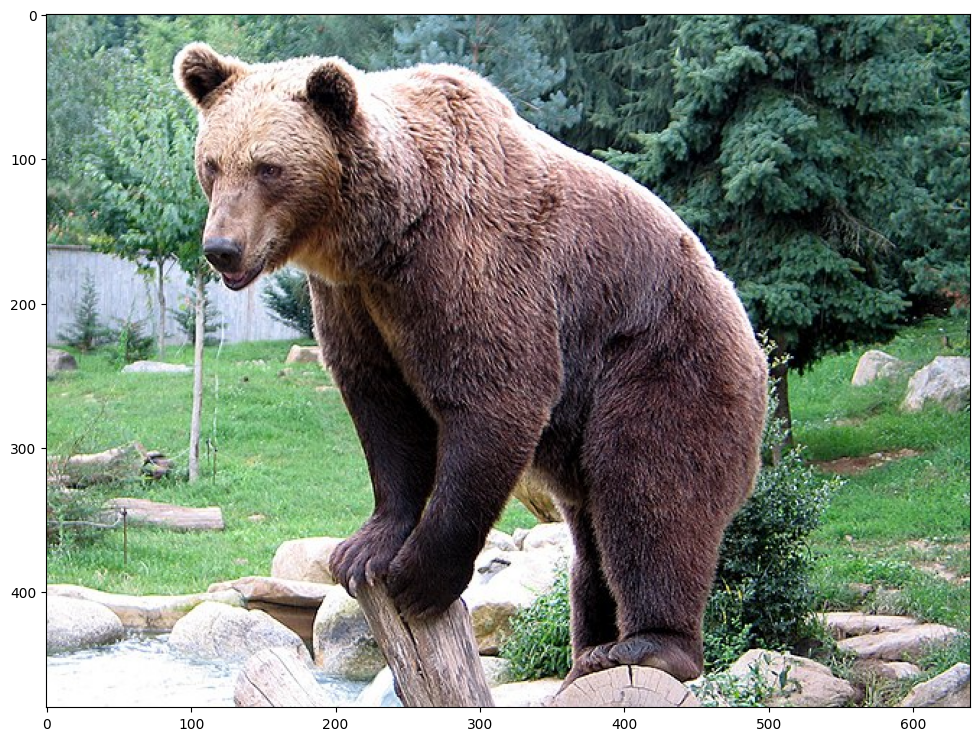

In [18]:
img = read_image("img/bear.jpg")[None]
plt.figure(figsize=(16, 9))
plt.imshow(img[0].permute(1, 2, 0));

In [21]:
with torch.no_grad():
    results = model(transforms(img))[0]
results

{'boxes': tensor([[ 93.2170,  17.8801, 497.0465, 469.4092]]),
 'labels': tensor([23]),
 'scores': tensor([0.9986])}

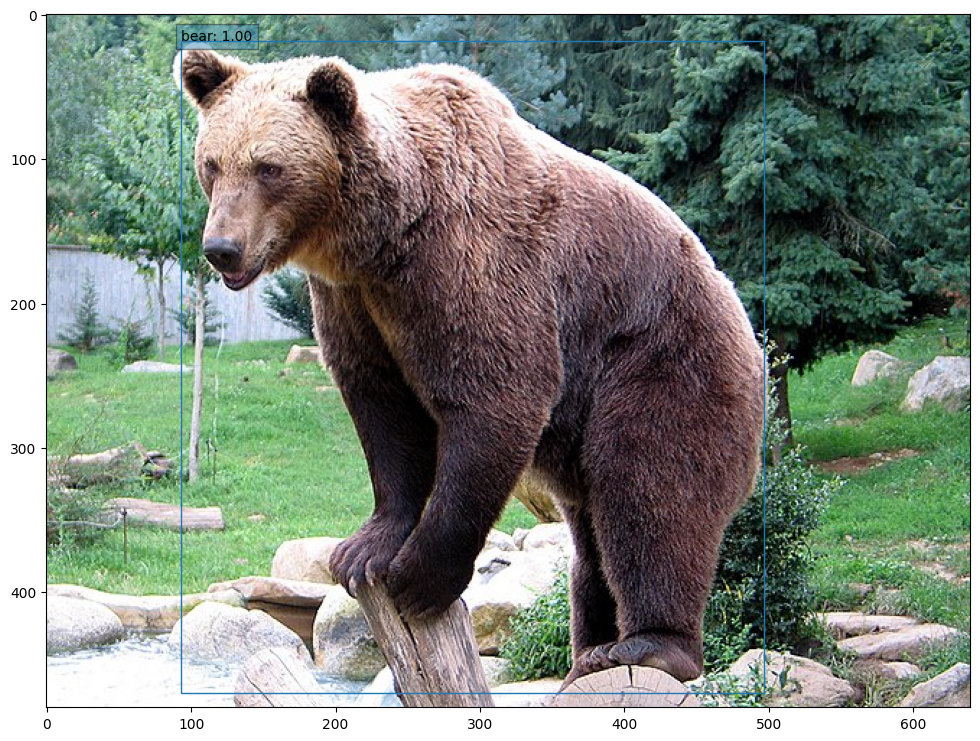

In [22]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(img[0].permute(1, 2, 0));

for i, score in enumerate(results["scores"]):
    category = categories[results["labels"][i]]
    x0, y0, x1, y1 = results["boxes"][i]
    rect = patches.Rectangle((x0, y0), (x1 - x0), (y1 - y0), fill=False, ec=f"C{i}")
    ax.text(x0, y0, f"{category}: {score:.2f}", bbox={"facecolor": f"C{i}", "alpha": 0.4})
    ax.add_patch(rect)